> **Extended study:** [Notebook 09](09_nn_architecture_all_elections.IPYNB) covers every election from 1997 through 2024, with ten-seed confirmation of all four architectures and detailed analysis of 1997 and 2010. The findings below remain the original three-election study. See [the updated report](nn_architecture_study/REPORT.md).

# Neural network architecture, learning-rate and early-stopping study

This extends notebook 06 without changing the pipeline or examining 2024. The task is to choose a reproducible **training procedure**, rather than find a favourable single election score.

## Protocol fixed before running

- Historical windows: train through **2015 / 2005 / 1997**, validate on **2017 / 2010 / 2001**, evaluate on **2019 / 2015 / 2005**, respectively.
- Hidden layers: **16**, **32**, **32 → 16** (existing baseline), **64 → 32**. ReLU throughout, with a five-class output.
- Learning rates: **0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0**.
- Early-stopping patience: **10, 20, 50**; restore the minimum validation cross-entropy checkpoint, minimum improvement zero, 1,000-epoch safety cap.
- Fixed: SGD without momentum or weight decay, batch size 64, cross-entropy, same predictors, training-only imputation/scaling/encoding, no election splitting.
- Screen: first **three matched seeds** for every architecture and learning rate.
- Confirm: **ten matched seeds** for the existing 32/16 architecture and the strongest alternative. The alternative is selected by mean validation log loss across windows after local learning-rate selection at patience 20, not by next-election scores.

Patience comparisons share a single deterministic training trajectory per architecture/rate/seed/window. Each rule freezes its own predictions at its first stopping point; later improvements cannot alter a shorter-patience result. A separate reference check verifies equivalence to independent fits.

## Limits of the evidence

These are **development backtests**. Earlier evaluation elections appear in later training windows; architecture shortlisting uses all validation windows, and historical results were already inspected. Next-election outcomes are excluded from checkpoint and local learning-rate selection, but selecting a final overall recipe after reading this study is still retrospective. The three windows are correlated, and seed variability is not uncertainty across future elections. No significance or independent-test claim is made. See [scikit-learn's explanation of selection bias](https://scikit-learn.org/1.6/auto_examples/model_selection/plot_nested_cross_validation_iris.html).

Learning-rate selection uses ensemble validation log loss. Development comparisons show equal-election mean accuracy as the primary descriptive ranking, alongside worst-election accuracy, changed-seat accuracy, log loss and Brier score. This is not an instruction to automatically deploy the highest row.

Metrics: accuracy is the fraction of correctly predicted constituency winners; changed-seat accuracy restricts to seats whose known previous winner differs from the outcome. Log loss uses natural logarithms and clips zero probabilities at float64 machine epsilon. Brier score is the unscaled multiclass sum of squared probability errors (range 0–2). Lower log loss and Brier scores are better. Election-level metrics are averaged equally, rather than treating all constituencies as independent electoral environments.

## Completed-study findings

- **No decisive architecture winner:** retain 32/16 as a defensible existing baseline; the larger network did not show a clear screening advantage.
- **Learning-rate search can be narrowed to 0.1/0.2/0.3/0.5** for 32/16 without changing its selected results here. Fixed 0.3 is a simpler competitive option; fixed 0.5 modestly improves retrospective accuracy.
- **Keep patience 20:** increasing it to 50 did not improve either finalist's selected-ensemble results. Patience 10 has some favourable combinations but no consistent advantage across procedures.
- **The network has not established consistent baseline superiority.** The full-search 32/16 procedure averages 82.60% next-election accuracy versus 87.22% for the previous-winner rule; it beats that rule on 2019 but loses on 2015 and 2005.

Read [the detailed report](nn_architecture_study/REPORT.md) for the numerical trade-offs and limitations. The executed tables below retain all results, including alternatives that outperform these defaults on particular metrics.

In [1]:
from pathlib import Path
import importlib.util
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "TEST_TRAIN/train.csv").exists())
RESULTS = ROOT / "Analysis and model development/nn_architecture_study"
# Default: inspect the saved completed study. True reruns/resumes the exact protocol.
RUN_STUDY = False
if RUN_STUDY:
    spec = importlib.util.spec_from_file_location("nn_architecture_study", RESULTS / "study.py")
    study = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(study)
    study.main()
configuration = json.loads((RESULTS / "configuration.json").read_text())
finalists = json.loads((RESULTS / "finalists.json").read_text())
screen = pd.read_csv(RESULTS / "screening_results.csv")
confirmed = pd.read_csv(RESULTS / "confirmation_results.csv")
policies = pd.read_csv(RESULTS / "confirmation_policies.csv")
summary = pd.read_csv(RESULTS / "confirmation_policy_summary.csv")
records = pd.read_csv(RESULTS / "confirmation_training_records.csv")
baselines = pd.read_csv(RESULTS / "baselines.csv")
print("Ten-seed finalists:", finalists["architectures"])
print("Data SHA-256:", configuration["data_sha256"])
display(baselines)


Ten-seed finalists: ['32_16', '16']
Data SHA-256: a7a5f0792357932573fa6eb7601ac6212aea63927a1e95bf7129fce8b341724f
   train_through  evaluation_year  ... changed_seat_accuracy  rows
0           2015             2019  ...              0.000000   632
1           2015             2019  ...              0.013158   632
2           2005             2015  ...              0.000000   632
3           2005             2015  ...              0.201835   632
4           1997             2005  ...              0.000000   628
5           1997             2005  ...              0.017544   628

[6 rows x 6 columns]


## Architecture screening

The screen measures both width and depth while preserving all other settings. Parameter counts depend on the categories observed in each training window. Compare validation-selected learning rates first; individual rates are diagnostic, not additional independent experiments.

,architecture,validation_year,learning_rate,validation_log_loss,evaluation_year,evaluation_accuracy,evaluation_changed_seat_accuracy,evaluation_log_loss
11,16,2017,0.05,0.293653,2019,0.867089,0.118421,0.317393
44,32,2017,0.01,0.313511,2019,0.867089,0.263158,0.298232
77,32_16,2017,0.30,0.309736,2019,0.890823,0.263158,0.268992
110,64_32,2017,0.30,0.306589,2019,0.895570,0.342105,0.262912
143,16,2010,0.30,0.270425,2015,0.770570,0.128440,0.827842
176,32,2010,0.10,0.274306,2015,0.742089,0.137615,0.900481
209,32_16,2010,0.50,0.267148,2015,0.780063,0.110092,0.838143
242,64_32,2010,0.30,0.271648,2015,0.762658,0.137615,0.851381
275,16,2001,0.20,0.163873,2005,0.799363,0.631579,0.464205
308,32,2001,0.50,0.167996,2005,0.804140,0.631579,0.435637


,mean_validation_log_loss,mean_evaluation_accuracy,worst_evaluation_accuracy
architecture,,,
16,0.242650,0.812340,0.770570
32,0.251938,0.804439,0.742089
32_16,0.252470,0.829255,0.780063
64_32,0.252488,0.826628,0.762658


train_through,1997,2005,2015
architecture,,,
16,549,581,581
32,1093,1157,1157
32_16,1541,1605,1605
64_32,4101,4229,4229


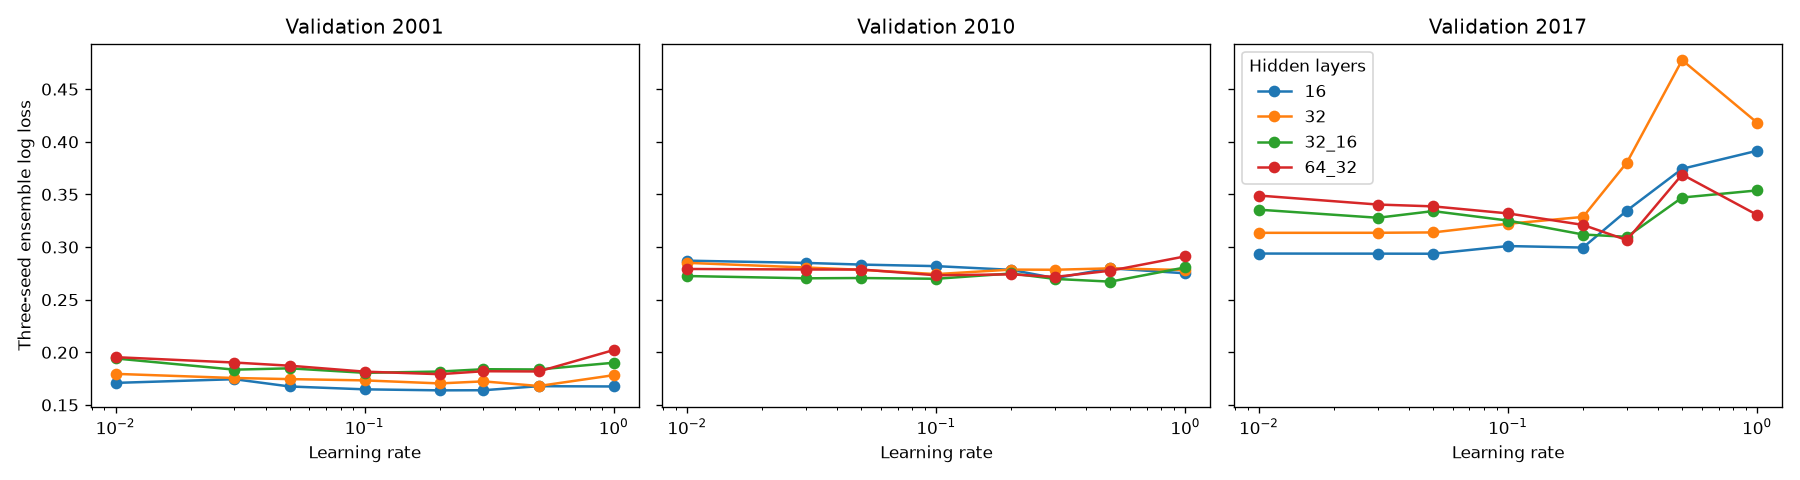

In [2]:
screen_policies = pd.read_csv(RESULTS / "screening_policies.csv")
selected = screen_policies.loc[(screen_policies.policy == "validation_all_rates") & (screen_policies.patience.astype(str) == "20")]
display(selected[["architecture", "validation_year", "learning_rate", "validation_log_loss", "evaluation_year", "evaluation_accuracy", "evaluation_changed_seat_accuracy", "evaluation_log_loss"]])
display(selected.groupby("architecture").agg(mean_validation_log_loss=("validation_log_loss", "mean"), mean_evaluation_accuracy=("evaluation_accuracy", "mean"), worst_evaluation_accuracy=("evaluation_accuracy", "min")))
screen_records = pd.read_csv(RESULTS / "screening_training_records.csv")
display(screen_records.groupby(["architecture", "train_through"]).parameters.first().unstack())
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, year in zip(axes, [2001, 2010, 2017]):
    for arch, g in screen.loc[(screen.validation_year == year) & (screen.patience == 20)].groupby("architecture"):
        ax.plot(g.learning_rate, g.validation_log_loss, marker="o", label=arch)
    ax.set_xscale("log"); ax.set_title(f"Validation {year}"); ax.set_xlabel("Learning rate")
axes[0].set_ylabel("Three-seed ensemble log loss"); axes[-1].legend(title="Hidden layers")
fig.tight_layout(); fig.savefig(RESULTS / "architecture_screen.png", dpi=150); plt.show()


## Ten-seed confirmation and learning-rate candidates

The larger ensemble checks whether three-seed rankings survive. All eight learning rates remain in confirmation: the search does not drop inconvenient rates. `validation_all_rates` chooses locally from eight rates; `validation_midrange` chooses from 0.1/0.2/0.3/0.5; `validation_compact` chooses from 0.1/0.3. Fixed-rate policies are included for comparison. Candidate subsets are development comparisons, not independently validated improvements.

,architecture,patience,policy,mean_accuracy,worst_accuracy,mean_changed_accuracy,mean_log_loss,mean_brier
14,16,20,fixed_0.3,0.829752,0.775316,0.404193,0.498171,0.247532
15,16,50,fixed_0.3,0.829752,0.775316,0.404193,0.498171,0.247532
17,32_16,10,validation_compact,0.829215,0.787975,0.374685,0.493432,0.246037
18,32_16,10,fixed_0.3,0.829215,0.787975,0.374685,0.493432,0.246037
19,32_16,20,validation_compact,0.829215,0.787975,0.365913,0.495011,0.247397
20,32_16,20,fixed_0.3,0.829215,0.787975,0.365913,0.495011,0.247397
21,32_16,50,fixed_0.3,0.829215,0.787975,0.365913,0.495011,0.247397
22,16,10,fixed_0.3,0.828170,0.770570,0.398077,0.492615,0.247559
25,32_16,20,validation_all_rates,0.826030,0.787975,0.365913,0.501433,0.251738
26,32_16,20,validation_midrange,0.826030,0.787975,0.365913,0.501433,0.251738


,architecture,validation_year,learning_rate,evaluation_year,evaluation_accuracy,evaluation_changed_seat_accuracy,evaluation_log_loss
11,32_16,2017,0.30,2019,0.901899,0.355263,0.243704
44,16,2017,0.05,2019,0.882911,0.223684,0.296044
77,32_16,2010,0.30,2015,0.787975,0.128440,0.789720
110,16,2010,0.50,2015,0.773734,0.128440,0.822665
143,32_16,2001,0.20,2005,0.788217,0.614035,0.470875
176,16,2001,0.20,2005,0.805732,0.614035,0.432846


mean_validation_log_loss  ...  mean_log_loss
architecture learning_rate                            ...               
16           0.01                           0.248532  ...       0.507958
             0.03                           0.247612  ...       0.503694
             0.05                           0.246011  ...       0.513457
             0.10                           0.244741  ...       0.502876
             0.20                           0.244433  ...       0.505510
             0.30                           0.258560  ...       0.498171
             0.50                           0.265824  ...       0.484947
             1.00                           0.266617  ...       0.515367
32_16        0.01                           0.269477  ...       0.489015
             0.03                           0.264583  ...       0.497458
             0.05                           0.262442  ...       0.492990
             0.10                           0.257368  ...       0.498468
             0.20                           0.255569  ...       0.497560
             0.30                           0.252445  ...       0.495011
             0.50                           0.260406  ...       0.496886
             1.00                           0.267316  ...       0.531647

[16 rows x 5 columns]

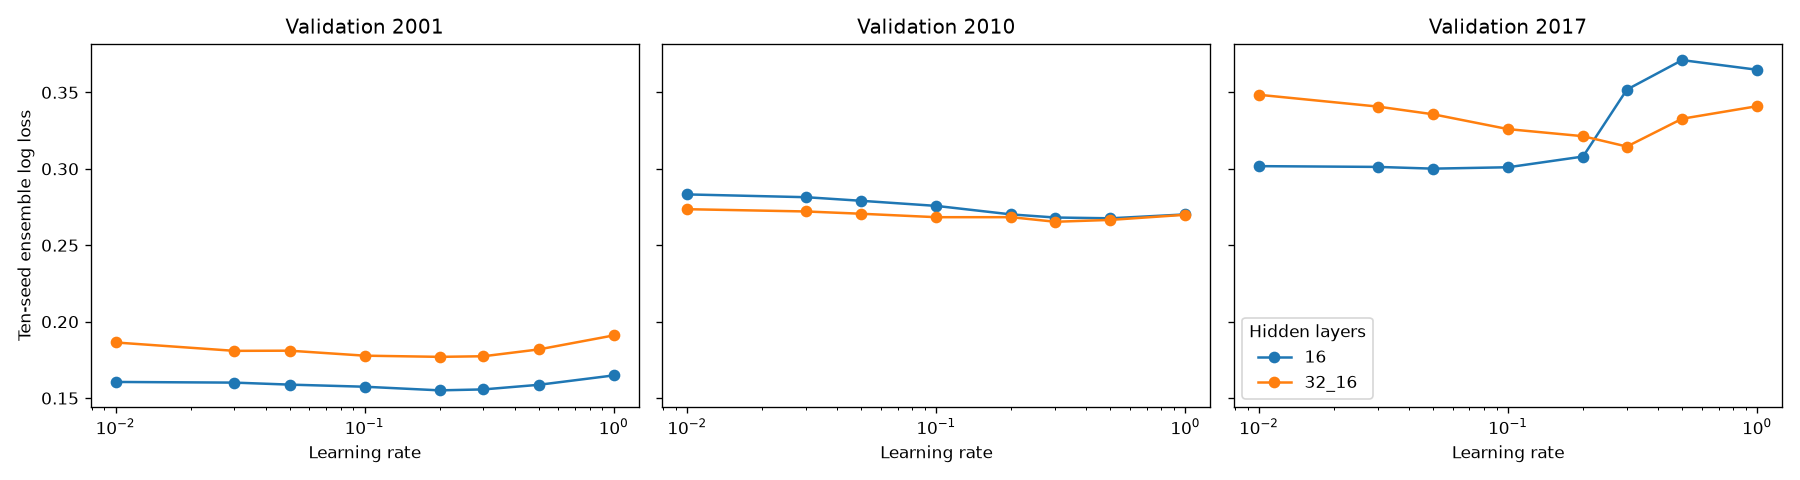

In [3]:
key = ["architecture", "patience", "policy", "mean_accuracy", "worst_accuracy", "mean_changed_accuracy", "mean_log_loss", "mean_brier"]
main = summary.loc[summary.policy.isin(["validation_all_rates", "validation_midrange", "validation_compact", "fixed_0.3", "validation_rate_and_patience"])]
display(main[key])
display(policies.loc[(policies.policy == "validation_all_rates") & (policies.patience.astype(str) == "20"),
                     ["architecture", "validation_year", "learning_rate", "evaluation_year", "evaluation_accuracy", "evaluation_changed_seat_accuracy", "evaluation_log_loss"]])
# Full rate results at the original patience, with one row per architecture/rate.
rate_comparison = confirmed.loc[confirmed.patience == 20].groupby(["architecture", "learning_rate"]).agg(
    mean_validation_log_loss=("validation_log_loss", "mean"), mean_accuracy=("evaluation_accuracy", "mean"),
    worst_accuracy=("evaluation_accuracy", "min"), mean_changed_accuracy=("evaluation_changed_seat_accuracy", "mean"),
    mean_log_loss=("evaluation_log_loss", "mean"))
display(rate_comparison)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, year in zip(axes, [2001, 2010, 2017]):
    for arch, g in confirmed.loc[(confirmed.validation_year == year) & (confirmed.patience == 20)].groupby("architecture"):
        ax.plot(g.learning_rate, g.validation_log_loss, marker="o", label=arch)
    ax.set_xscale("log"); ax.set_title(f"Validation {year}"); ax.set_xlabel("Learning rate")
axes[0].set_ylabel("Ten-seed ensemble log loss"); axes[-1].legend(title="Hidden layers")
fig.tight_layout(); fig.savefig(RESULTS / "confirmed_learning_rates.png", dpi=150); plt.show()


## Early stopping and convergence

Longer patience means more opportunities to improve validation loss; it need not improve future-election performance. The checkpoint chosen by each seed can differ. Reaching the safety cap is flagged; it does not prove convergence. Selecting patience on the validation election is shown as a separate policy, not mixed into the fixed-patience comparison.

Confirmed runs reaching the cap, across patience records: 0


,architecture,patience,validation_year,learning_rate,evaluation_year,evaluation_accuracy,evaluation_changed_seat_accuracy,evaluation_log_loss
0,32_16,10,2017,0.30,2019,0.901899,0.381579,0.238966
11,32_16,20,2017,0.30,2019,0.901899,0.355263,0.243704
22,32_16,50,2017,0.30,2019,0.901899,0.355263,0.243704
33,16,10,2017,0.05,2019,0.882911,0.223684,0.296044
44,16,20,2017,0.05,2019,0.882911,0.223684,0.296044
55,16,50,2017,0.05,2019,0.882911,0.223684,0.296044
66,32_16,10,2010,0.50,2015,0.786392,0.119266,0.819578
77,32_16,20,2010,0.30,2015,0.787975,0.128440,0.789720
88,32_16,50,2010,0.30,2015,0.787975,0.128440,0.789720
99,16,10,2010,0.30,2015,0.770570,0.128440,0.811525


mean_best_epoch  ...  capped_runs
architecture patience learning_rate                   ...             
16           10       0.01                135.466667  ...            0
                      0.03                 43.200000  ...            0
                      0.05                 29.500000  ...            0
                      0.10                 15.100000  ...            0
                      0.20                  9.700000  ...            0
                      0.30                  8.333333  ...            0
                      0.50                  5.733333  ...            0
                      1.00                  4.800000  ...            0
             20       0.01                197.633333  ...            0
                      0.03                 64.266667  ...            0
                      0.05                 43.000000  ...            0
                      0.10                 22.366667  ...            0
                      0.20                 11.500000  ...            0
                      0.30                  9.366667  ...            0
                      0.50                  8.500000  ...            0
                      1.00                  6.233333  ...            0
             50       0.01                233.200000  ...            0
                      0.03                 74.433333  ...            0
                      0.05                 47.000000  ...            0
                      0.10                 24.533333  ...            0
                      0.20                 12.266667  ...            0
                      0.30                  9.366667  ...            0
                      0.50                 10.966667  ...            0
                      1.00                  6.233333  ...            0
32_16        10       0.01                103.033333  ...            0
                      0.03                 40.333333  ...            0
                      0.05                 25.133333  ...            0
                      0.10                 15.300000  ...            0
                      0.20                  8.400000  ...            0
                      0.30                  6.533333  ...            0
                      0.50                  5.433333  ...            0
                      1.00                  5.966667  ...            0
             20       0.01                135.033333  ...            0
                      0.03                 50.866667  ...            0
                      0.05                 28.500000  ...            0
                      0.10                 15.666667  ...            0
                      0.20                  8.766667  ...            0
                      0.30                  6.966667  ...            0
                      0.50                  6.766667  ...            0
                      1.00                  6.433333  ...            0
             50       0.01                159.233333  ...            0
                      0.03                 55.533333  ...            0
                      0.05                 29.266667  ...            0
                      0.10                 17.566667  ...            0
                      0.20                  8.766667  ...            0
                      0.30                  6.966667  ...            0
                      0.50                  7.566667  ...            0
                      1.00                  9.566667  ...            0

[48 rows x 4 columns]

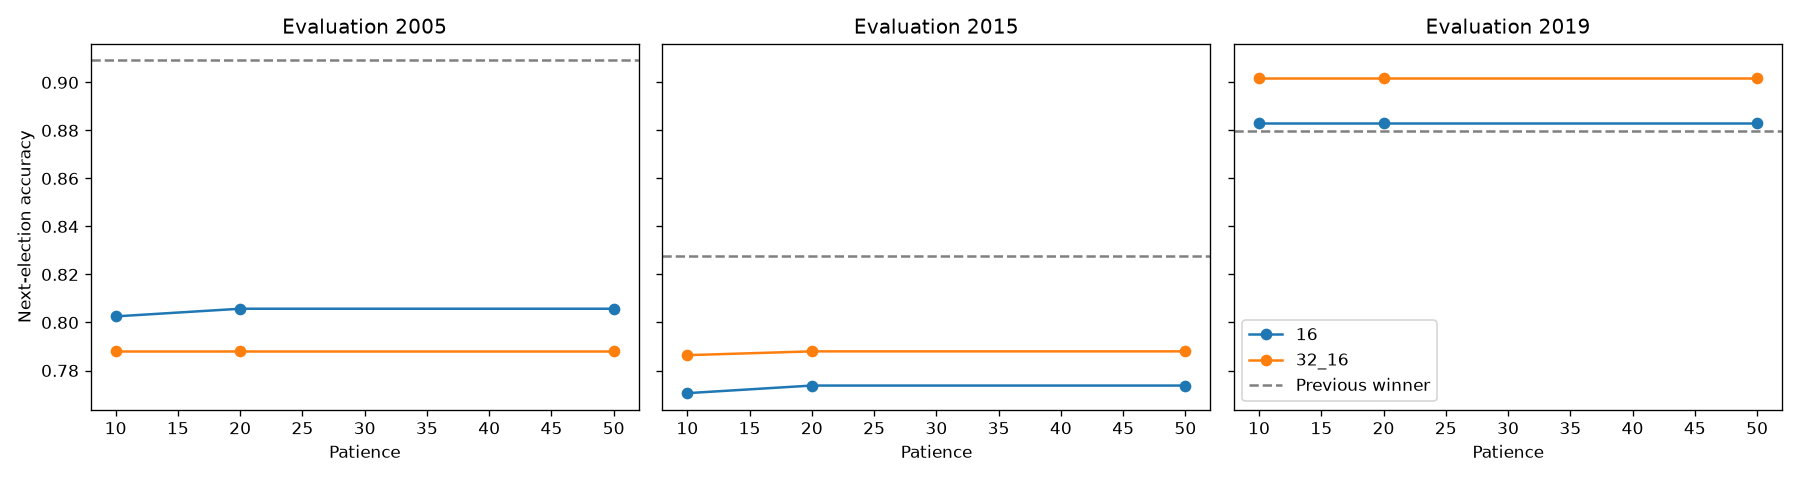

In [4]:
stopping = policies.loc[policies.policy == "validation_all_rates"]
display(stopping[["architecture", "patience", "validation_year", "learning_rate", "evaluation_year", "evaluation_accuracy", "evaluation_changed_seat_accuracy", "evaluation_log_loss"]])
diagnostics = records.groupby(["architecture", "patience", "learning_rate"]).agg(
    mean_best_epoch=("best_epoch", "mean"), max_best_epoch=("best_epoch", "max"),
    mean_stopping_epoch=("stopping_epoch", "mean"), capped_runs=("hit_epoch_cap", "sum"))
display(diagnostics)
print("Confirmed runs reaching the cap, across patience records:", int(records.hit_epoch_cap.sum()))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, year in zip(axes, [2005, 2015, 2019]):
    for arch, g in stopping.loc[stopping.evaluation_year == year].groupby("architecture"):
        ax.plot(g.patience.astype(int), g.evaluation_accuracy, marker="o", label=arch)
    baseline = baselines.loc[(baselines.evaluation_year == year) & (baselines.baseline == "previous_winner"), "accuracy"].iloc[0]
    ax.axhline(baseline, color="grey", linestyle="--", label="Previous winner")
    ax.set_title(f"Evaluation {year}"); ax.set_xlabel("Patience")
axes[0].set_ylabel("Next-election accuracy"); axes[-1].legend()
fig.tight_layout(); fig.savefig(RESULTS / "patience_comparison.png", dpi=150); plt.show()


## Seed stability and per-party errors

Individual-network spread describes optimisation sensitivity. It is not a confidence interval for future elections. Per-party recall below uses the all-rate validation selector at patience 20; high overall accuracy can hide poor minority-party performance or weak detection of changed seats.

In [5]:
display(records.groupby(["architecture", "patience", "validation_year", "learning_rate"]).agg(
    seed_validation_accuracy_mean=("validation_accuracy", "mean"),
    seed_validation_accuracy_sd=("validation_accuracy", "std"),
    seed_validation_loss_sd=("best_validation_loss", "std")))
predictions = pd.read_csv(RESULTS / "confirmation_predictions.csv.gz")
party_rows = []
for row in policies.loc[(policies.policy == "validation_all_rates") & (policies.patience.astype(str) == "20")].itertuples():
    frame = predictions.loc[(predictions.split == "evaluation") & (predictions.train_through == row.train_through)
                            & (predictions.architecture == row.architecture) & (predictions.learning_rate == row.learning_rate)
                            & (predictions.patience == 20)].copy()
    probability_columns = [c for c in frame if c.startswith("p_")]
    predicted = frame[probability_columns].idxmax(axis=1).str.removeprefix("p_")
    frame["correct"] = predicted == frame.winner
    for party, g in frame.groupby("winner"):
        party_rows.append(dict(architecture=row.architecture, evaluation_year=row.evaluation_year,
                               party=party, actual_seats=len(g), predicted_seats=int((predicted == party).sum()),
                               recall=g.correct.mean(),
                               precision=float(g.correct.sum() / (predicted == party).sum()) if (predicted == party).any() else np.nan))
party_results = pd.DataFrame(party_rows)
display(party_results)
party_results.to_csv(RESULTS / "per_party_recall.csv", index=False)


seed_validation_accuracy_mean  ...  seed_validation_loss_sd
architecture patience validation_year learning_rate                                 ...                         
16           10       2001            0.01                                0.946802  ...                 0.016792
                                      0.03                                0.946646  ...                 0.026165
                                      0.05                                0.950702  ...                 0.023046
                                      0.10                                0.952418  ...                 0.016830
                                      0.20                                0.954914  ...                 0.009537
...                                                                            ...  ...                      ...
32_16        50       2017            0.10                                0.876424  ...                 0.033682
                                      0.20                                0.873101  ...                 0.033134
                                      0.30                                0.891930  ...                 0.036642
                                      0.50                                0.887500  ...                 0.043921
                                      1.00                                0.880380  ...                 0.075421

[144 rows x 3 columns]

,architecture,evaluation_year,party,actual_seats,predicted_seats,recall,precision
0,32_16,2019,con,365,351,0.904110,0.940171
1,32_16,2019,lab,202,235,0.975248,0.838298
2,32_16,2019,lib,11,1,0.090909,1.000000
3,32_16,2019,natSW,52,45,0.807692,0.933333
4,32_16,2019,oth,2,0,0.000000,NaN
5,16,2019,con,365,350,0.890411,0.928571
6,16,2019,lab,202,245,0.975248,0.804082
7,16,2019,lib,11,5,0.363636,0.800000
8,16,2019,natSW,52,32,0.615385,1.000000
9,16,2019,oth,2,0,0.000000,NaN


## Reading the results and transferring a procedure later

1. Look for architecture gains that survive ten-seed confirmation and appear in more than one period. A larger network is not automatically preferable.
2. Compare full-search, smaller candidate-set and fixed-rate policies. Keep a broad search only if its extra flexibility earns its place; do not confuse the best retrospective fixed rate with an independently validated choice.
3. Prefer a fixed, simple stopping rule when patience changes produce inconsistent benefits. Log loss and accuracy need not favour the same rule.
4. Check the previous-winner baseline, changed seats and party recalls before calling a network successful.
5. Freeze the chosen procedure before pipeline integration. The pipeline remains unchanged by this study. The 2019 comparison is now development evidence, and 2024 has not been read here.

All configuration-level results, per-seed diagnostics and ensemble probabilities are retained beside `study.py`. Temporary individual-run caches make interrupted execution resumable on this machine; the script can recreate them from the recorded data and configuration. `REPORT.md` records the interpretation of the completed run.